In [8]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import numpy as np

# --- SETTINGS ---
 

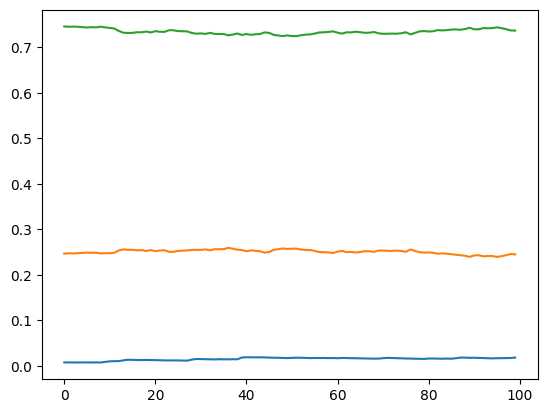

In [141]:
def numpy_ema(prices, span):
    alpha = 2 / (span + 1)
    ema = np.zeros_like(prices, dtype=float)
    
    # Seed initial value with first data point
    ema[0] = prices[0]
    
    for t in range(1, len(prices)):
        ema[t] = alpha * prices[t] + (1 - alpha) * ema[t - 1]
        
    return ema
#plt.plot(signal)



plt.plot(numpy_ema(signal, span=100))

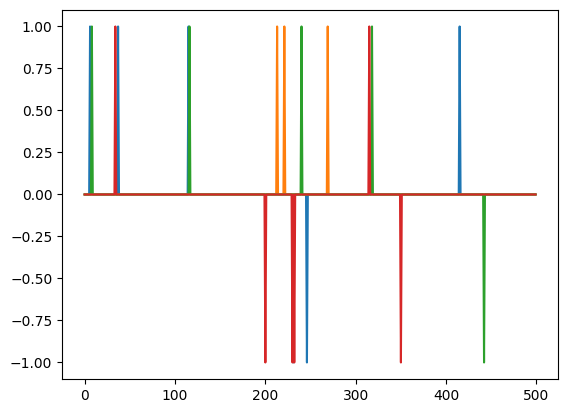

In [71]:
import numpy as np

# 1. Define your own explicit N x N covariance structure directly
#    (High value = high overlap, 0 = independent)
Sigma = np.array([
    [1.0,  0.8, -0.5,  0.0],
    [0.8,  1.0, -0.2,  0.1],
    [-0.5, -0.2,  1.0,  0.0],
    [0.0,  0.1,  0.0,  1.0]
])

N = Sigma.shape[0]
T = 500  # Number of time steps
tau = 2.5  # Controls proportion of 0s

# 2. Draw T timepoints directly from your covariance matrix
#    Output shape: (T, N) -> Transpose to (N, T) for N timecourses of length T
Z = np.random.multivariate_normal(mean=np.zeros(N), cov=Sigma, size=T).T

# 3. Apply threshold to get {-1, 0, 1}
X = np.select([Z > tau, Z < -tau], [1, -1], default=0)

plt.plot(X.T)

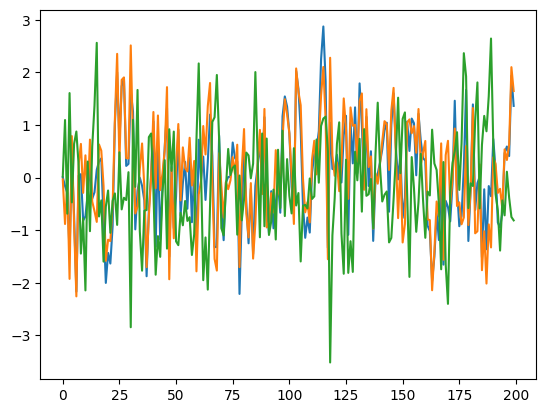

In [98]:
import numpy as np
from scipy.stats import matrix_normal

# 1. Define explicit Spatial Covariance (N x N)
# Example: 3 channels with custom overlap
Sigma_space = np.array([
    [1.0,  0.9,  0.0],
    [0.9,  1.0, -0.4],
    [0.0, -0.4,  1.0]
])
N = Sigma_space.shape[0]

# 2. Define explicit Temporal Covariance (T x T)
# Example: AR(1) autoregressive decay over T timepoints
T = 200
rho = 0.25  # Temporal autocorrelation strength
t_idx = np.arange(T)
Sigma_time = rho ** np.abs(np.subtract.outer(t_idx, t_idx))

# Regularize temporal matrix to prevent numerical Cholesky errors
Sigma_time += 1e-6 * np.eye(T)

# 3. Create SciPy Matrix Normal distribution and sample
# Result shape is (N, T)
rv = matrix_normal(mean=np.zeros((N, T)), rowcov=Sigma_space, colcov=Sigma_time)
Z = rv.rvs()

# 4. Threshold to ternary {-1, 0, 1}
tau = 1.5
X = np.select([Z > tau, Z < -tau], [1, -1], default=0)
X=Z
plt.plot(X.T)

array([[ 1.        , -0.00277825, -0.33755309],
       [-0.00277825,  1.        , -0.94036505],
       [-0.33755309, -0.94036505,  1.        ]])

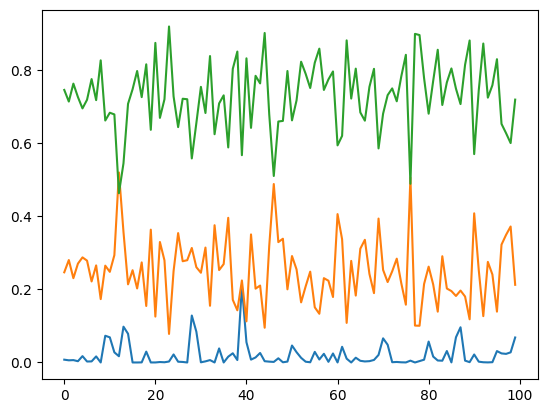

In [106]:
import numpy as np
from scipy.stats import dirichlet

quantiles = np.array([0.2, 0.2, 0.6])  # specify quantiles
alpha = np.array([0.4, 5, 15])  # specify concentration parameters
dirichlet.pdf(quantiles, alpha)

signal=dirichlet.rvs(alpha, size=100, random_state=1)

plt.plot(signal)

np.corrcoef(signal.T)


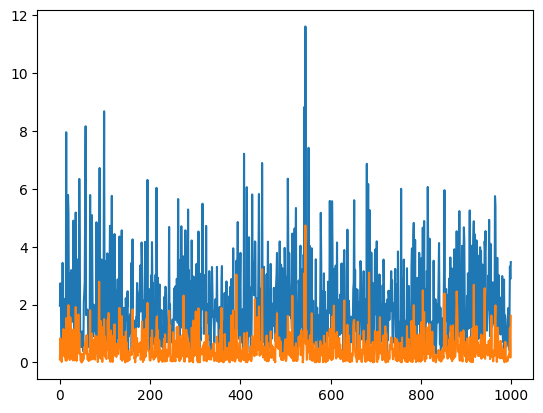

In [115]:
import numpy as np
from scipy.stats import norm, gamma, expon

n_samples = 1000

# 1. Define target correlation matrix and draw from multivariate normal
cov = [[1.0, 0.7], 
       [0.7, 1.0]]
mv_norm = np.random.multivariate_normal([0, 0], cov, size=n_samples)

# 2. Transform Gaussian margins to Uniform (0,1) using standard normal CDF
u = norm.cdf(mv_norm)

# 3. Apply Inverse CDF (quantile function) of desired marginal distributions
col_1 = gamma.ppf(u[:, 0], a=2)      # Gamma distribution
col_2 = expon.ppf(u[:, 1], scale=0.5)  # Exponential distribution

multivariate_data = np.column_stack([col_1, col_2])

plt.plot(multivariate_data)

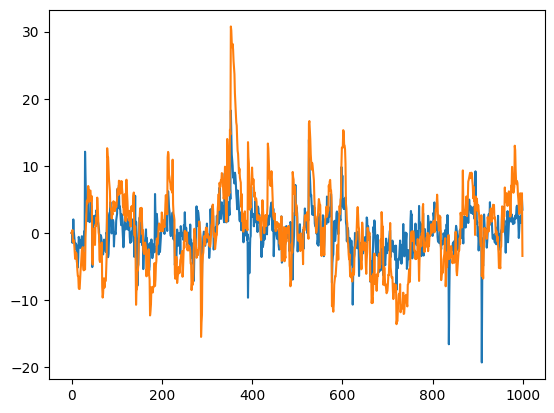

In [ ]:
import numpy as np
from scipy.stats import multivariate_t

n_steps = 1000

# 1. Define VAR(1) Coefficient Matrix (A) and Cross-Covariance
A = np.array([[0.6, 0.1],   # Autocorrelation & Cross-lag parameters
              [0.1, 0.9]])

shape_cov = np.array([[1.0, 0.4], 
                      [0.4, 1.0]])

# 2. Draw heavy-tailed innovations from Multivariate Student-t (df=4)
innovations = multivariate_t.rvs(shape=shape_cov, df=2, size=n_steps)

# 3. Simulate VAR(1) time series
data = np.zeros((n_steps, 2))
for t in range(1, n_steps):
    data[t] = A @ data[t-1] + innovations[t]

plt.plot(data)

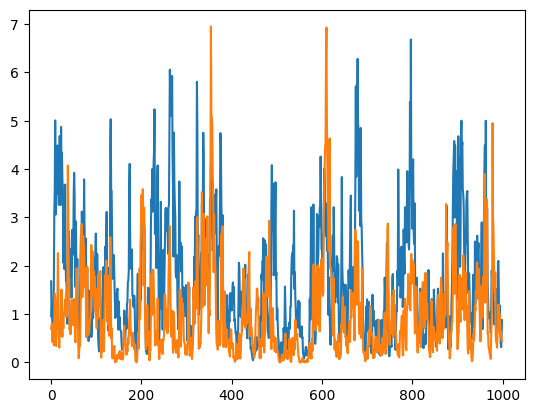

In [125]:
import numpy as np
from scipy.stats import norm, gamma, expon

def generate_var_non_normal(n_steps=1000, phi=0.8, cross_corr=0.6):
    """
    phi: Autocorrelation parameter (|phi| < 1)
    cross_corr: Correlation between variables
    """
    np.random.seed(42)
    
    # 1. Build covariance for standard normal innovations
    cov = [[1.0, cross_corr], 
           [cross_corr, 1.0]]
    
    # 2. Generate latent Vector Autoregressive VAR(1) process
    latent = np.zeros((n_steps, 2))
    innovations = np.random.multivariate_normal([0, 0], cov, size=n_steps)
    
    # Stationary variance adjustment
    innovations *= np.sqrt(1 - phi**2)
    
    for t in range(1, n_steps):
        latent[t] = phi * latent[t-1] + innovations[t]
        
    # 3. Probability Integral Transform (PIT) to Uniform(0,1)
    u = norm.cdf(latent)
    
    # 4. Map to target Non-Normal Marginals
    # Variable 1: Gamma(shape=2) | Variable 2: Exponential(scale=1)
    x1 = gamma.ppf(u[:, 0], a=2)
    x2 = expon.ppf(u[:, 1], scale=1)
    
    return np.column_stack([x1, x2])

# Generate time series
data = generate_var_non_normal(n_steps=1000, phi=0.85, cross_corr=0.5)
plt.plot(data)

In [166]:
# Generate random covariance matrix

import numpy as np


def generate_random_cov(n: int, k: int = None) -> np.ndarray:
    if k is None:
        k = n  # Ensure full rank

    # Step 1: Create a random factor matrix
    W = np.random.randn(n, k)

    # Step 2: Form Positive Semi-Definite matrix
    A = W @ W.T

    # Step 3: Normalize to get 1s on the diagonal
    d = np.sqrt(np.diag(A))
    sigma = A / np.outer(d, d)

    return sigma


# Example: 5x5 random covariance matrix
N = 5
sigma = generate_random_cov(N)

print(sigma)
# Verification: check diagonal elements are 1s and eigenvalues are >= 0
print("\nDiagonal:", np.diag(sigma))
print("Eigenvalues:", np.linalg.eigvalsh(sigma))

[[ 1.         -0.62137885 -0.12816247 -0.64155512 -0.48113015]
 [-0.62137885  1.         -0.21660479  0.65853277 -0.31909081]
 [-0.12816247 -0.21660479  1.         -0.50638182  0.3797306 ]
 [-0.64155512  0.65853277 -0.50638182  1.         -0.14420023]
 [-0.48113015 -0.31909081  0.3797306  -0.14420023  1.        ]]

Diagonal: [1. 1. 1. 1. 1.]
Eigenvalues: [2.27601385e-05 2.01034185e-01 7.32060782e-01 1.67793680e+00
 2.38894547e+00]


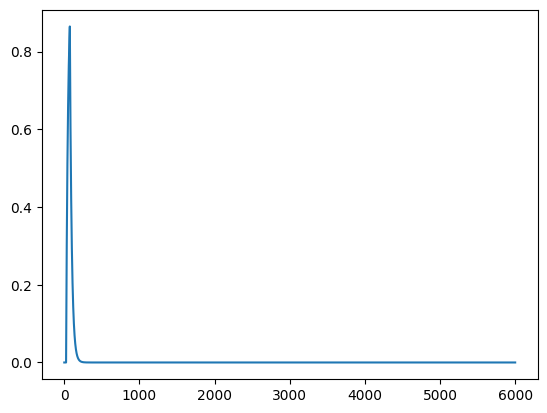

In [64]:

def numpy_ema(prices, span):
    alpha = 2 / (span + 1)
    ema = np.zeros_like(prices, dtype=float)
    # Seed initial value with first data point
    ema[0] = prices[0]
    for t in range(1, len(prices)):
        ema[t] = alpha * prices[t] + (1 - alpha) * ema[t - 1]
    return ema

N1 = 20         # Number of boxcars
N2 = 6000        # Total array size
offset=25
min_len = 50     # Minimum boxcar length
#max_len = 250    # Maximum boxcar length

# --- GENERATE BOXCARS ---
signal = np.zeros(N2)
signal[offset:offset+min_len]=1
    
signal=numpy_ema(signal, span=50)
plt.plot(signal)

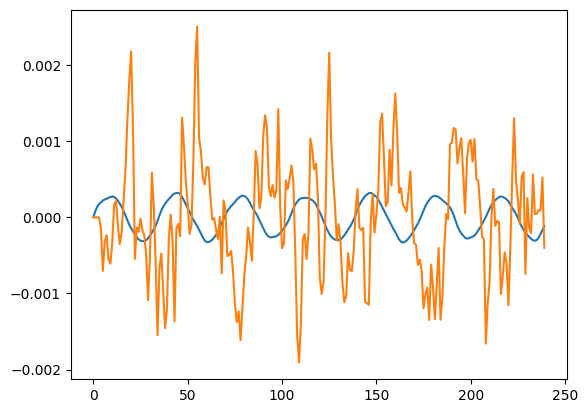

In [15]:
import matplotlib.pyplot as plt
import numpy as np
a=np.load('Results/frames.npy')

plt.plot(a.mean(axis=1))
plt.plot(a[:,4000])

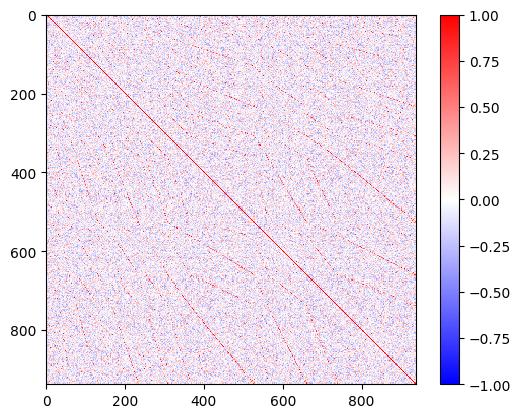

np.float64(0.001856243334563906)

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

aa=np.load('results/frames.npy')

aa_demeaned = aa - aa.mean(axis=1, keepdims=True)
corr_matrix, _ = stats.spearmanr(aa[50:150, ::10], axis=0)

plt.imshow(corr_matrix, interpolation="None",cmap='bwr',vmin=-1.0,vmax=1.0)
plt.colorbar()
plt.show()
# plt.plot(aa_demeaned.mean(axis=1))

corr_matrix.mean()

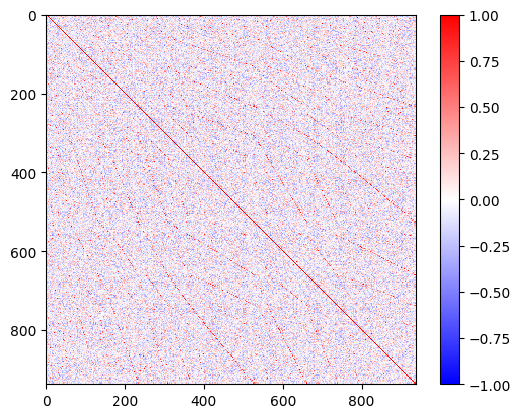

np.float64(0.001374365059091805)

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

aa=np.load('results/frames.npy')

aa_demeaned = aa - aa.mean(axis=1, keepdims=True)
corr_matrix2, _ = stats.spearmanr(aa[150:, ::10], axis=0)

plt.imshow(corr_matrix2, interpolation="None",cmap='bwr',vmin=-1.0,vmax=1.0)
plt.colorbar()
plt.show()
# plt.plot(aa_demeaned.mean(axis=1))

corr_matrix2.mean()

In [ ]:
np.corrcoef(corr_matrix2.flatten(),corr_matrix.flatten())



array([[1.        , 0.40359944],
       [0.40359944, 1.        ]])

/opt/homebrew/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


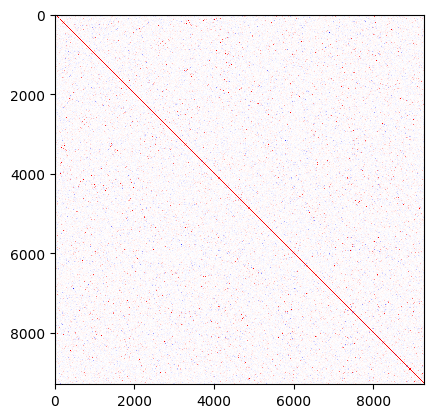

In [49]:
fc=np.load('results/fc/sub-MSC01_hemi-L_space-fsaverage5_mask-fsaverage_ses-01-02-03-04-05-06-07-08-09-10_spearmanfc.npy')

corr_matrix, _ = stats.spearmanr(aa[50:, ::], axis=0)

plt.imshow(fc, interpolation="None",cmap='bwr',vmin=-0.5,vmax=0.5)


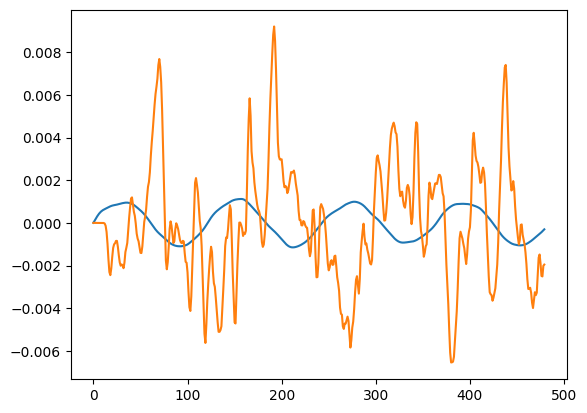

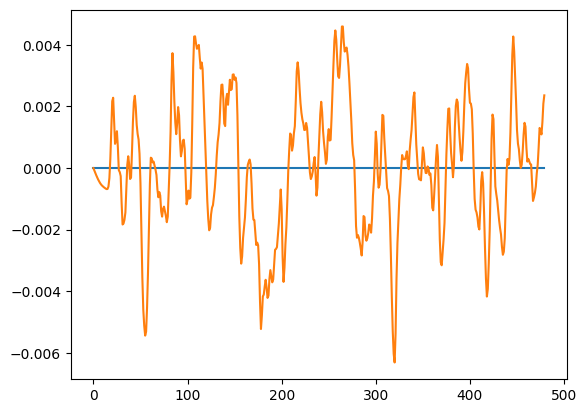

In [85]:
import numpy as np

a=np.load('results/frames.npy')
#corr_matrix, _ = stats.spearmanr(aa[50:, ::], axis=0)

plt.plot(a.mean(axis=1))
plt.plot(a[:,4000])
plt.show()
a_demeaned = a - a.mean(axis=1, keepdims=True)
plt.plot(a_demeaned.mean(axis=1))
plt.plot(a_demeaned[:,6000])
#fc=np.load('results/fc/sub-MSC01_hemi-L_space-fsaverage5_mask-fsaverage_ses-01-02-03-04-05-06-07-08-09-10_spearmanfc.npy')

#print(fc.shape)
#print(corr_matrix.shape)

In [86]:
%load_ext autoreload
%autoreload 2
from mesh_cache import load_cortex
from fc_score import FCTarget

cortex = load_cortex("fsaverage5")
target = FCTarget(cortex, fc_path='results/fc/group-NKI100_hemi-L_space-fsaverage5_mask-glasser_spearmandcfc.npy',burn=50,seed=23)
a=np.load('results/frames.npy')
a_demeaned = a - a.mean(axis=1, keepdims=True)
r = target.score(a)           # 0.6 s per candidate
print(r)
r = target.score(a_demeaned)           # 0.6 s per candidate
print(r)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[fsaverage5] cache: 9374 vertices, negative dual edges 0.025%
[FCTarget] group-NKI100_hemi-L_space-fsaverage5_mask-glasser_spearmandcfc.npy
           9217 vertices (157 of cortex.nV unmatched), 1999787 edges, metric=spearman, centre=none, burn=50
0.15552294254302979
0.2632088363170624


np.float64(0.0006962233042256866)

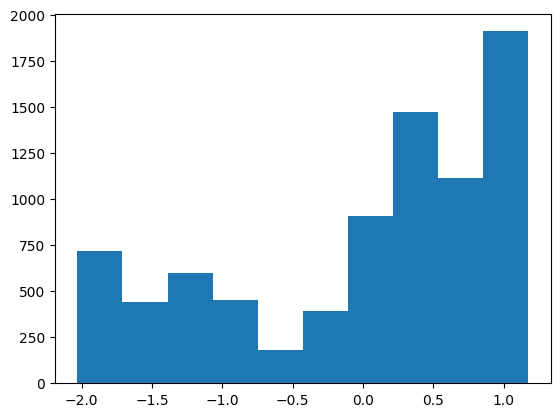

In [ ]:
import pandas as pd

df=pd.read_csv('/Users/robertleech/Downloads/The impact of the weekly cycle on conscious experience in daily life Data and Scripts 2/For Data Sharing/Data Files/DailyLife_mDES_only.csv')
plt.hist(df[df['Data_location']=="Canada"]['Focus'])
#np.mean(df[df['Data_location']=="Canada"]['Focus'])

